# Privacy-utility tradeoff on one-hot Criteo

Test PR-AUC against the privacy budget for three private optimizers, over one
partition (ADR-0020's encoding, 700,000 training rows, a 100,000-row validation
holdout, the loader's own 200,000 test rows), one initialization and one loss.
`bias_reduced_sgd`'s line stops at eps = 1: Lemma 5.3's amplification is stated
for eps <= 1 and its `train` raises above it. 09 is the next free number in the
one global sequence (ADR-0019).

## 1. Imports

In [1]:
import os

# The two sweeps below run configurations concurrently on one device and the
# pool is sized against what the allocator will hand out. JAX reads this once,
# at import, and takes 75% of the device without it.
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.8")

import math
import time
from concurrent.futures import ThreadPoolExecutor
from typing import NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dimma.accounting import bias_reduced_sgd as brs_accounting
from dimma.accounting import spiderboost as spiderboost_accounting
from dimma.accounting.lipschitz import logreg_bce_constants
from dimma.accounting.sampling import (
    PoissonGaussianSchedule,
    calibrate_noise_multiplier,
    poisson_gaussian_epsilon,
)
from dimma.algorithms.bias_reduced_sgd import train as bias_reduced_sgd
from dimma.algorithms.dp_sgd import train as dp_sgd
from dimma.algorithms.sgd import train as sgd
from dimma.algorithms.spiderboost import train as spiderboost
from dimma.core import updates
from dimma.core.sampling import poisson
from dimma.datasets.criteo import load_criteo_one_hot
from dimma.metrics.calibration import expected_calibration_error
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss
from dimma.models.logreg import forward_sparse, init_params

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


## 2. Data and sweep configuration

One block fixes the protocol; `SMOKE` moves only the run sizes and the grids.
The four arms share the budget, the delta, the accountant, the partition, the
initialization and the loss, and differ only in the mechanism.

In [2]:
SMOKE = False                     # True runs toy sizes; False is the committed run

# ---- the protocol. Identical across the four arms. ----------------------
FEATURE_NORM_BOUND = 2.0          # enforced by the loader, not measured
TARGET_DELTA = 1e-12              # below 1 / n ** 2; asserted with the data
ACCOUNTANT = "rdp"                # ADR-0011, held fixed across all three arms
EPSILONS = (0.1, 0.3, 1.0, 3.0, 10.0)
BRS_EPSILON_CEILING = 1.0         # Lemma 5.3; train raises above it
REFERENCE_EPSILON = 1.0           # largest budget all three private arms share
N_BINS = 15                       # equal-mass bins, as everywhere in notebooks/
VALIDATION_ROWS = 100_000         # cut off the 800,000 training rows
INIT_SEED = 0                     # the one initialization, every run, every arm
BASE_SEED = 20260823              # the sampling and noise streams move off this
SPARSITY = 40                     # 39 stored features and the bias (ADR-0020)
PADDING_MARGIN_SIGMAS = 8.0       # Poisson padding caps; not privacy parameters

# Sensitivity parity. SpiderBoost has no clipping stage and takes L0 as an
# assumption from the enforced R (ADR-0009, ADR-0012); DP-SGD and
# bias_reduced_sgd bound the same quantity by clipping to it. One number,
# enforced on two arms and assumed on the third.
CONSTANTS = logreg_bce_constants(FEATURE_NORM_BOUND, has_bias=True)
CLIP_NORM = CONSTANTS.lipschitz_constant
BRS_RADIUS = CLIP_NORM * math.sqrt(SPARSITY)

# ---- what SMOKE moves, and all it moves. --------------------------------
if SMOKE:
    STEPS = 100
    BATCH = 1024
    ANCHOR_INTERVAL = 4
    B1, B2 = 1024, 256
    BRS_MAX_SCALE = 8
    SWEEP_EPSILONS = (1.0, 3.0)
    SGD_LR_GRID = (1.0, 3.0)
    DP_LR_GRID = (0.3, 1.0)
    SB_STEP_SCALES = (1.0, 4.0)
    BRS_LR_GRID = (1e-3, 1e-2)
else:
    STEPS = 3_000
    BATCH = 1024
    ANCHOR_INTERVAL = 4
    B1, B2 = 4096, 1024
    BRS_MAX_SCALE = 10
    SWEEP_EPSILONS = EPSILONS
    SGD_LR_GRID = (0.3, 1.0, 3.0, 10.0)
    DP_LR_GRID = (0.3, 1.0, 3.0, 10.0)
    SB_STEP_SCALES = (1.0, 4.0, 16.0, 64.0)
    BRS_LR_GRID = (1e-4, 1e-3, 1e-2, 1e-1)

# Theorem B.3's step size is the unit the SpiderBoost grid is stated in.
SB_LR_GRID = tuple(scale * CONSTANTS.step_size for scale in SB_STEP_SCALES)
BUDGET_EPSILONS = tuple(dict.fromkeys((REFERENCE_EPSILON, *SWEEP_EPSILONS)))

print(f"SMOKE = {SMOKE}   steps = {STEPS:,}   batch = {BATCH:,}   "
      f"q = {ANCHOR_INTERVAL}   b1/b2 = {B1}/{B2}   max_scale = {BRS_MAX_SCALE}")
print(f"R = {FEATURE_NORM_BOUND}  ->  L0 = {CONSTANTS.lipschitz_constant:.6f}, "
      f"L1 = {CONSTANTS.smoothness_constant:.6f}, "
      f"eta = {CONSTANTS.step_size:.6f}")
print(f"clip_norm = L0 = {CLIP_NORM:.6f} on DP-SGD and bias_reduced_sgd; "
      f"brs radius = L0 * sqrt({SPARSITY}) = {BRS_RADIUS:.4f}")
print(f"sweep: {SWEEP_EPSILONS}, bias_reduced_sgd only at eps <= "
      f"{BRS_EPSILON_CEILING:g}")

SMOKE = False   steps = 3,000   batch = 1,024   q = 4   b1/b2 = 4096/1024   max_scale = 10
R = 2.0  ->  L0 = 2.236068, L1 = 1.250000, eta = 0.400000
clip_norm = L0 = 2.236068 on DP-SGD and bias_reduced_sgd; brs radius = L0 * sqrt(40) = 14.1421
sweep: (0.1, 0.3, 1.0, 3.0, 10.0), bias_reduced_sgd only at eps <= 1


In [3]:
split = load_criteo_one_hot(preprocess=True, download=False, seed=INIT_SEED,
                            device=DEVICE, feature_norm_bound=FEATURE_NORM_BOUND)

n_all, STORED_PER_ROW = split.idx_train.shape
N_FEATURES = split.num_features

# One deterministic cut of the training split: a permutation at a fixed seed,
# held out once and never re-drawn: the bias-reduced-SGD comparison's rows.
holdout = np.random.default_rng(BASE_SEED).permutation(n_all)
val_index = jnp.asarray(holdout[:VALIDATION_ROWS])
train_index = jnp.asarray(holdout[VALIDATION_ROWS:])

IDX_TRAIN, VAL_TRAIN = split.idx_train[train_index], split.val_train[train_index]
IDX_VAL, VAL_VAL = split.idx_train[val_index], split.val_train[val_index]
IDX_TEST, VAL_TEST = split.idx_test, split.val_test
Y_TRAIN = split.y_train[train_index]
Y_VAL = np.asarray(split.y_train[val_index], dtype=np.float64)
Y_TEST = np.asarray(split.y_test, dtype=np.float64)

n_train = int(IDX_TRAIN.shape[0])
BASE_RATE = float(Y_TEST.mean())

# bias_reduced_sgd's stopping-time bound (Lemma 5.5) needs delta below 1/n**2.
assert TARGET_DELTA < 1 / n_train ** 2, (
    f"delta = {TARGET_DELTA:.0e} must sit below 1 / n ** 2 = "
    f"{1 / n_train ** 2:.3e} for the stopping-time bound to hold")

print(f"train {IDX_TRAIN.shape}   validation {IDX_VAL.shape}   "
      f"test {IDX_TEST.shape}")
print(f"{N_FEATURES:,} feature coordinates, {STORED_PER_ROW} stored a row")
print(f"test base rate {BASE_RATE:.4f}  (the PR-AUC floor)")
print(f"delta precondition: 1 / n ** 2 = {1 / n_train ** 2:.3e} against "
      f"delta = {TARGET_DELTA:.0e}  ->  holds")

criteo: 39 features as index/value pairs. I1-I13 at indices 0-12: NaN filled with the train-split median, clipped below at 0, then log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26 one-hot at their native train-split cardinalities, each column holding its own block of the index space and one slot reserved for IDs unseen in the training split, so every row carries exactly 39 entries whatever it holds. Not standardized: centring a one-hot column fills it, and the sparsity is the point. Every row then rescaled to l2 norm at most 2.0, one record at a time.
E0823 18:47:49.986699 2141933 cuda_executor.cc:1176] [0] Failed to allocate device memory of 37.89GiB (40686845952 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:45
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla/xla/strea

train (700000, 39)   validation (100000, 39)   test (200000, 39)
551,947 feature coordinates, 39 stored a row
test base rate 0.2520  (the PR-AUC floor)
delta precondition: 1 / n ** 2 = 2.041e-12 against delta = 1e-12  ->  holds


In [4]:
# A dimma per-sample loss is (params, x_single, y_single) -> scalar and every
# train slices x along one leading axis, so the indices and the values travel
# as one array. The bias-reduced-SGD comparison's, lifted unchanged.
X_TRAIN = jnp.concatenate([IDX_TRAIN.astype(jnp.float32), VAL_TRAIN], axis=1)
assert (np.asarray(X_TRAIN[:, :STORED_PER_ROW]).astype(np.int64)
        == np.asarray(IDX_TRAIN)).all(), "index round-trip is not exact"


def per_sample_sparse_bce(params, packed, y):
    """BCE for one example held as concatenated indices and values."""
    idx = packed[:STORED_PER_ROW].astype(jnp.int32)
    val = packed[STORED_PER_ROW:]
    logit = forward_sparse(params, idx, val)
    return jax.nn.softplus(logit) - logit * y


def fresh_params():
    """The one starting point, shared by every run in this notebook."""
    return init_params(jax.random.key(INIT_SEED), N_FEATURES)


assert "b" in fresh_params(), (
    "the shipped logreg carries a bias; has_bias=True above would be a "
    "false epsilon without it")

print(f"packed training features {X_TRAIN.shape} {X_TRAIN.dtype}, "
      f"{X_TRAIN.nbytes / 1e6:.0f} MB on {DEVICE}")

packed training features (700000, 78) float32, 218 MB on gpu


In [5]:
SAMPLING_RATE = BATCH / n_train


def dp_budget(target_epsilon):
    """The DP-SGD multiplier for one budget, and the epsilon it prices back."""
    def schedule(multiplier):
        return [PoissonGaussianSchedule(SAMPLING_RATE, multiplier, STEPS)]

    sigma = calibrate_noise_multiplier(schedule, target_epsilon, TARGET_DELTA,
                                       method=ACCOUNTANT)
    spent = poisson_gaussian_epsilon(SAMPLING_RATE, sigma, STEPS, TARGET_DELTA,
                                     method=ACCOUNTANT)
    assert spent <= target_epsilon + 1e-9
    return sigma, spent


def sb_budget(target_epsilon):
    """The three SpiderBoost scales for one budget, and the epsilon back."""
    scales = spiderboost_accounting.noise_scales(
        lipschitz_constant=CONSTANTS.lipschitz_constant,
        smoothness_constant=CONSTANTS.smoothness_constant,
        target_epsilon=target_epsilon, target_delta=TARGET_DELTA,
        steps=STEPS, anchor_interval=ANCHOR_INTERVAL,
        anchor_expected_batch_size=B1, variation_expected_batch_size=B2,
        dataset_size=n_train, method=ACCOUNTANT,
    )
    spent = spiderboost_accounting.epsilon(
        lipschitz_constant=CONSTANTS.lipschitz_constant,
        smoothness_constant=CONSTANTS.smoothness_constant,
        anchor_noise_scale=scales.anchor_noise_scale,
        variation_noise_rate=scales.variation_noise_rate,
        variation_noise_cap=scales.variation_noise_cap,
        target_delta=TARGET_DELTA, steps=STEPS,
        anchor_interval=ANCHOR_INTERVAL,
        anchor_expected_batch_size=B1, variation_expected_batch_size=B2,
        dataset_size=n_train, method=ACCOUNTANT,
    )
    assert spent <= target_epsilon + 1e-9
    return scales, spent


t0 = time.time()
DP_SIGMA, SB_SCALES, DP_EPSILON, SB_EPSILON = {}, {}, {}, {}
print(f"{'eps':>6} {'DP sigma':>10} {'DP eps back':>12} {'sigma_1':>11} "
      f"{'sigma_2':>11} {'sigma_2 cap':>12} {'SB eps back':>12} "
      f"{'brs multiplier':>15}")
for eps in sorted(BUDGET_EPSILONS):
    sigma, dp_back = dp_budget(eps)
    scales, sb_back = sb_budget(eps)
    DP_SIGMA[eps], SB_SCALES[eps] = sigma, scales
    DP_EPSILON[eps], SB_EPSILON[eps] = dp_back, sb_back
    brs = (f"{brs_accounting.inner_noise_multiplier(target_epsilon=eps, target_delta=TARGET_DELTA):>15.1f}"
           if eps <= BRS_EPSILON_CEILING else f"{'-- refused --':>15}")
    print(f"{eps:>6g} {sigma:>10.4f} {dp_back:>12.6f} "
          f"{scales.anchor_noise_scale:>11.4e} "
          f"{scales.variation_noise_rate:>11.4e} "
          f"{scales.variation_noise_cap:>12.4e} {sb_back:>12.6f} {brs}")
print(f"\n{len(BUDGET_EPSILONS)} budgets calibrated in {time.time() - t0:.1f}s "
      f"(method {ACCOUNTANT!r}); every epsilon above is recomputed from the "
      f"scales the loop is handed. bias_reduced_sgd is not calibrated at all: "
      f"its multiplier is a closed form in (eps, delta).")

   eps   DP sigma  DP eps back     sigma_1     sigma_2  sigma_2 cap  SB eps back  brs multiplier


   0.1     6.2626     0.099982  6.2972e-03  1.4081e-02   5.0378e-02     0.100000          2504.5


   0.3     3.1300     0.299999  2.2080e-03  4.9372e-03   1.7664e-02     0.300000           834.8


     1     1.4243     0.999998  9.4503e-04  2.1132e-03   7.5602e-03     0.999999           250.4


     3     0.8738     2.999991  5.5732e-04  1.2462e-03   4.4586e-03     2.999999   -- refused --


    10     0.5565     9.999999  3.5053e-04  7.8381e-04   2.8042e-03     9.999968   -- refused --

5 budgets calibrated in 3.5s (method 'rdp'); every epsilon above is recomputed from the scales the loop is handed. bias_reduced_sgd is not calibrated at all: its multiplier is a closed form in (eps, delta).


In [6]:
BYTES_PER_FLOAT32 = 4
HEADROOM_BYTES = 2 * 1024 ** 3
GPU = jax.devices()[0]


def cap_for(expected_batch_size):
    """This run's Poisson padding cap for one branch. Not a privacy parameter."""
    return poisson.padded_batch_size(expected_batch_size, n_train,
                                     margin_sigmas=PADDING_MARGIN_SIGMAS)


# jax.grad of a logit that gathers 40 coordinates still returns a (551947,) row
# per example, so any arm needing per-example gradients allocates a dense
# (B, d) float32 block. Plain SGD differentiates the mean and pays none of it.
DP_BATCH_CAP, ANCHOR_CAP, VARIATION_CAP = cap_for(BATCH), cap_for(B1), cap_for(B2)
BLOCKS = {
    "SGD": 0,
    "DP-SGD": DP_BATCH_CAP * N_FEATURES * BYTES_PER_FLOAT32,
    "SpiderBoost": ANCHOR_CAP * N_FEATURES * BYTES_PER_FLOAT32,
    "bias_reduced_sgd": (1 << (BRS_MAX_SCALE + 1)) * N_FEATURES * BYTES_PER_FLOAT32,
}


def pool_size(blocks):
    """Workers whose simultaneous worst case still fits in free device memory."""
    stats = GPU.memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"] - HEADROOM_BYTES
    total, workers = 0, 0
    for block in sorted(blocks, reverse=True):
        if total + block > free:
            break
        total, workers = total + block, workers + 1
    return max(1, min(workers, len(blocks)))


def concurrently(jobs, label):
    """Run one job (block_bytes, thunk) per thread; outcomes come back in order."""
    workers = pool_size([block for block, _ in jobs])
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        outcomes = list(pool.map(lambda job: job[1](), jobs))
    print(f"{label}: {len(jobs)} runs, {workers} at a time, "
          f"{time.time() - t0:.0f}s on {DEVICE}\n")
    return outcomes


print(f"the allocator will hand out {GPU.memory_stats()['bytes_limit'] / 1e9:.1f} GB")
print(f"{'arm':<20}{'padded batch':>14}{'dense grad block':>19}")
print(f"{'SGD':<20}{BATCH:>14,}{'none':>19}")
print(f"{'DP-SGD':<20}{DP_BATCH_CAP:>14,}{BLOCKS['DP-SGD'] / 1e9:>16.2f} GB")
print(f"{'SpiderBoost':<20}{ANCHOR_CAP:>14,}"
      f"{BLOCKS['SpiderBoost'] / 1e9:>16.2f} GB   (variation cap "
      f"{VARIATION_CAP:,})")
print(f"{'bias_reduced_sgd':<20}{1 << (BRS_MAX_SCALE + 1):>14,}"
      f"{BLOCKS['bias_reduced_sgd'] / 1e9:>16.2f} GB")

the allocator will hand out 40.7 GB
arm                   padded batch   dense grad block
SGD                          1,024               none
DP-SGD                       1,284            2.83 GB
SpiderBoost                  4,611           10.18 GB   (variation cap 1,284)
bias_reduced_sgd             2,048            4.52 GB


In [7]:
class Run(NamedTuple):
    """One trained arm: the iterate it reports, and what it spent."""

    params: object
    steps: int
    epsilon: float
    """`nan` for the non-private arm, which carries no epsilon at all."""


def streams(seed_index):
    """The two seeds one run gets. Both fold off `seed_index` alone."""
    return (jax.random.key(BASE_SEED + seed_index),
            np.random.default_rng([BASE_SEED, seed_index]))


def train_arm(arm, learning_rate, target_epsilon, seed_index):
    """Train one arm at one learning rate and one budget, from the shared start."""
    key, rng = streams(seed_index)
    optimizer = updates.sgd(learning_rate)
    if arm == "SGD":
        trained = sgd.train(per_sample_sparse_bce, fresh_params(), optimizer,
                            X_TRAIN, Y_TRAIN, rng,
                            steps=STEPS, batch_size=BATCH)
        return Run(params=trained, steps=STEPS, epsilon=float("nan"))
    if arm == "DP-SGD":
        trained = dp_sgd.train(per_sample_sparse_bce, fresh_params(), optimizer,
                               X_TRAIN, Y_TRAIN, key, rng,
                               steps=STEPS, expected_batch_size=BATCH,
                               clip_norm=CLIP_NORM,
                               noise_multiplier=DP_SIGMA[target_epsilon],
                               b_max=DP_BATCH_CAP)
        return Run(params=trained, steps=STEPS,
                   epsilon=DP_EPSILON[target_epsilon])
    if arm == "SpiderBoost":
        scales = SB_SCALES[target_epsilon]
        # The first return is w-bar, the output rule's iterate; the last
        # iterate carries no bound and is never reported.
        output_params, _ = spiderboost.train(
            per_sample_sparse_bce, fresh_params(), optimizer,
            X_TRAIN, Y_TRAIN, key, rng,
            steps=STEPS, anchor_interval=ANCHOR_INTERVAL,
            anchor_expected_batch_size=B1, variation_expected_batch_size=B2,
            anchor_noise_scale=scales.anchor_noise_scale,
            variation_noise_rate=scales.variation_noise_rate,
            variation_noise_cap=scales.variation_noise_cap,
            anchor_b_max=ANCHOR_CAP, variation_b_max=VARIATION_CAP,
        )
        return Run(params=output_params, steps=STEPS,
                   epsilon=SB_EPSILON[target_epsilon])
    run = bias_reduced_sgd.train(
        per_sample_sparse_bce, fresh_params(), optimizer,
        X_TRAIN, Y_TRAIN, key, rng,
        target_epsilon=target_epsilon, target_delta=TARGET_DELTA,
        clip_norm=CLIP_NORM, radius=BRS_RADIUS,
        max_scale=BRS_MAX_SCALE, max_steps=STEPS,
    )
    spent = brs_accounting.epsilon(run.spent, target_delta=TARGET_DELTA)
    # x-bar, the convex output rule, is what Theorem 5.6 bounds.
    return Run(params=run.average_params, steps=run.steps, epsilon=spent)


ARMS = ("SGD", "DP-SGD", "SpiderBoost", "bias_reduced_sgd")
PRIVATE_ARMS = ARMS[1:]
LR_GRIDS = {"SGD": SGD_LR_GRID, "DP-SGD": DP_LR_GRID,
            "SpiderBoost": SB_LR_GRID, "bias_reduced_sgd": BRS_LR_GRID}
print("four arms, one loss function object, one initialization, "
      f"{STEPS:,} steps each")

four arms, one loss function object, one initialization, 3,000 steps each


## 3. Metric helper

One evaluator, three threshold-free numbers, on whichever split it is handed.
PR-AUC is the headline; no ROC-AUC and no accuracy (ADR-0016). Non-finite
logits return `nan` rather than crashing the sweep.

In [8]:
_score = jax.jit(jax.vmap(forward_sparse, in_axes=(None, 0, 0)))


class Eval(NamedTuple):
    """What one parameter set scores on one split."""

    loss: float
    pr_auc: float
    ece: float


NAN_EVAL = Eval(float("nan"), float("nan"), float("nan"))


def evaluate_at(params, idx, val, labels):
    """Score one parameter set on one split, `nan` where it diverged.

    `dimma.metrics` raises on non-finite input rather than returning nan,
    so the guard sits in front of it. bias_reduced_sgd returns host
    float64 parameters and the model runs in float32, so the cast is here.
    """
    float32 = jax.tree.map(lambda leaf: jnp.asarray(leaf, jnp.float32), params)
    logits = _score(float32, idx, val)
    if not np.all(np.isfinite(np.asarray(logits))):
        return NAN_EVAL
    probs = np.asarray(jax.nn.sigmoid(logits), dtype=np.float64)
    return Eval(loss=log_loss(probs, labels),
                pr_auc=pr_curve(probs, labels).average_precision,
                ece=expected_calibration_error(probs, labels, n_bins=N_BINS))


def on_validation(params):
    """The selection split. Section 4 reads this and only this."""
    return evaluate_at(params, IDX_VAL, VAL_VAL, Y_VAL)


def on_test(params):
    """The reporting split. Not read before section 5."""
    return evaluate_at(params, IDX_TEST, VAL_TEST, Y_TEST)

## 4. Learning rate, picked once per arm

Each arm's grid runs once, at the reference budget eps = 1.0 — the largest all
three private arms share — and is selected on validation log-loss, nan-safe.
Nothing else in this notebook is tuned, and the four winners are frozen here.
SpiderBoost and `bias_reduced_sgd` both select the first point of their grid,
so those two axes are an edge and not a bracket; neither is extended a second
time here.

In [9]:
tuning_keys, tuning_jobs = [], []
for arm in ARMS:
    for offset, learning_rate in enumerate(LR_GRIDS[arm]):
        seed_index = 100 * (ARMS.index(arm) + 1) + offset
        tuning_keys.append((arm, learning_rate))
        tuning_jobs.append((
            BLOCKS[arm],
            lambda a=arm, lr=learning_rate, s=seed_index: train_arm(
                a, lr, REFERENCE_EPSILON, s),
        ))

tuning_runs = concurrently(tuning_jobs, f"learning-rate grids at eps = "
                                       f"{REFERENCE_EPSILON:g}")

scored = {arm: [] for arm in ARMS}
for (arm, learning_rate), run in zip(tuning_keys, tuning_runs):
    scored[arm].append((learning_rate, on_validation(run.params)))

BEST_LR = {}
print(f"{'arm':<20}{'lr':>10} {'val log-loss':>13} {'val PR-AUC':>11} "
      f"{'val ECE':>9}")
for arm in ARMS:
    finite = [(lr, ev) for lr, ev in scored[arm] if np.isfinite(ev.loss)]
    if not finite:
        raise RuntimeError(
            f"every learning rate in {arm}'s grid diverged; the grid is "
            f"wrong for this partition, not the arm")
    BEST_LR[arm] = min(finite, key=lambda row: row[1].loss)[0]
    for learning_rate, ev in scored[arm]:
        mark = "  <- selected" if learning_rate == BEST_LR[arm] else ""
        print(f"{arm:<20}{learning_rate:>10.4g} {ev.loss:>13.4f} "
              f"{ev.pr_auc:>11.4f} {ev.ece:>9.4f}{mark}")

print(f"\nfrozen: " + ",  ".join(f"{arm} lr = {BEST_LR[arm]:g}" for arm in ARMS))

E0823 18:48:07.630237 2142225 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


learning-rate grids at eps = 1: 16 runs, 3 at a time, 472s on gpu



arm                         lr  val log-loss  val PR-AUC   val ECE
SGD                        0.3        0.5000      0.4810    0.0243
SGD                          1        0.4887      0.5027    0.0131
SGD                          3        0.4807      0.5207    0.0136  <- selected
SGD                         10        0.6329      0.5297    0.2227
DP-SGD                     0.3        0.5006      0.4790    0.0235
DP-SGD                       1        0.4918      0.4956    0.0080  <- selected
DP-SGD                       3        0.5042      0.4750    0.0302
DP-SGD                      10        0.6584      0.4170    0.1269
SpiderBoost                0.4        0.5089      0.4654    0.0330  <- selected
SpiderBoost                1.6        0.5236      0.4356    0.0395
SpiderBoost                6.4        1.4158      0.3499    0.2448
SpiderBoost               25.6        4.7727      0.3329    0.3005
bias_reduced_sgd        0.0001        0.6958      0.2605    0.2522  <- selected
bias_reduc

## 5. The epsilon sweep

Every private arm at its frozen learning rate, one run per budget, scored on
test. `bias_reduced_sgd` runs only at eps <= 1; its realized step count and
realized epsilon are outputs of the filter, not inputs to it (ADR-0018). The
non-private SGD baseline is one epsilon-free run.

The filter's delta arm, not its epsilon arm, is what stops the run, so a
larger budget buys `bias_reduced_sgd` quieter steps and never more of them and
its realized step count sits at `max_steps` at every budget it runs at. The
three lines also do not share an accountant: `bias_reduced_sgd` is priced by
Theorem A.4's filter, which is advanced composition and over-reports, while
DP-SGD and Private SpiderBoost are priced by the Renyi accountant (ADR-0018).
A horizontal cut across the plot is therefore a comparison of mechanisms and
of accountants at once.

The `bias_reduced_sgd` arm stopped at `max_steps`, a wall-clock guard, and not
at the filter: its realized epsilon reads 0.000643, 0.002073 and 0.007517
against budgets of 0.1, 0.3 and 1.0, under 1% of what it was handed at every
point. Its flat line is not a measurement of what a budget buys it, and the
`init` row of the table says why: the three points are the initialization.
Every arm starts at test PR-AUC 0.2630 and log-loss 0.6959, and this one
reports 0.2629, 0.2581 and 0.2632 at 0.6959, 0.6953 and 0.6958. Section 4
selected the smallest learning rate of its grid for it, and it then did not
leave the point it started from, so the three budgets agree because none of
them trained anything. The agreement therefore says nothing about what the
tenfold fall in the inner noise multiplier — 2504.5 to 250.4 — would have
bought an arm that was moving.

What this arm is short of is signal in a step, not steps. The bias-reduced-SGD
sweep measures the ratio that decides it: one debiased estimate carries an
error 828 times the length of the gradient it estimates — a ratio that sweep
shows to be invariant in the clipping norm, so it carries to the larger `C`
this notebook runs — and averaging that out needs 685,401 steps while the
filter admits 94,073 at `max_scale = 10`. A run taken all the way to the
filter is therefore still a factor of seven short of parity, which is why the
sweep's own lengths and the 3,000 here reach the same negative, and why the
bias-reduced-SGD comparison reports it too. Stopping early is privacy-sound in
any case, being strictly less access to the data, but it forfeits Section
5.3.1's lower bound on the stopping time and with it the accuracy theorem,
exactly as `bias_reduced_sgd.train`'s `max_steps` docstring states; running to
the filter is about an hour a point, which is why it is not done here.

In [10]:
sweep_keys, sweep_jobs = [(None, "SGD")], [
    (BLOCKS["SGD"],
     lambda: train_arm("SGD", BEST_LR["SGD"], REFERENCE_EPSILON, 1)),
]
for offset, eps in enumerate(SWEEP_EPSILONS):
    for arm in PRIVATE_ARMS:
        if arm == "bias_reduced_sgd" and eps > BRS_EPSILON_CEILING:
            continue
        seed_index = 1_000 + 10 * offset + PRIVATE_ARMS.index(arm)
        sweep_keys.append((eps, arm))
        sweep_jobs.append((
            BLOCKS[arm],
            lambda a=arm, e=eps, s=seed_index: train_arm(a, BEST_LR[a], e, s),
        ))

sweep_runs = concurrently(sweep_jobs, "epsilon sweep")

# The point all four arms start from. An arm that scores it has not moved,
# which is what the private lines below are read against.
INITIAL = on_test(fresh_params())

RESULTS = {arm: {} for arm in PRIVATE_ARMS}
BRS_REALIZED = {}
for (eps, arm), run in zip(sweep_keys, sweep_runs):
    result = on_test(run.params)
    if arm == "SGD":
        BASELINE = result
        continue
    RESULTS[arm][eps] = result
    if arm == "bias_reduced_sgd":
        BRS_REALIZED[eps] = (run.steps, run.epsilon)

print(f"non-private SGD at lr = {BEST_LR['SGD']:g}: test PR-AUC "
      f"{BASELINE.pr_auc:.4f}, test log-loss {BASELINE.loss:.4f}   "
      f"(epsilon-free)")
print(f"the shared initialization: test PR-AUC {INITIAL.pr_auc:.4f}, "
      f"test log-loss {INITIAL.loss:.4f}   (every arm starts here)")
print(f"test base rate {BASE_RATE:.4f} is the PR-AUC floor\n")

SHORT = {"DP-SGD": "DP-SGD", "SpiderBoost": "SpiderBoost",
         "bias_reduced_sgd": "bias_reduced_sgd"}
print(f"{'':>6}" + "".join(f"{SHORT[arm]:>19}" for arm in PRIVATE_ARMS)
      + f"{'brs steps':>11}{'brs eps':>10}")
print(f"{'eps':>6}" + "".join(f"{'PR-AUC':>10}{'log-loss':>9}"
                              for _ in PRIVATE_ARMS)
      + f"{'realized':>11}{'realized':>10}")
for eps in SWEEP_EPSILONS:
    row = f"{eps:>6g}"
    for arm in PRIVATE_ARMS:
        result = RESULTS[arm].get(eps)
        row += (f"{result.pr_auc:>10.4f}{result.loss:>9.4f}" if result
                else f"{'--':>10}{'--':>9}")
    steps, realized = BRS_REALIZED.get(eps, (None, None))
    row += (f"{steps:>11,}{realized:>10.4f}" if steps is not None
            else f"{'--':>11}{'--':>10}")
    print(row)
print(f"{'init':>6}" + "".join(
    f"{INITIAL.pr_auc:>10.4f}{INITIAL.loss:>9.4f}" for _ in PRIVATE_ARMS)
      + f"{'--':>11}{'--':>10}")
print(f"\nthe init row is one number repeated: every arm starts from the same "
      f"parameters, so each column is read against it.")
print(f"bias_reduced_sgd is absent above eps = {BRS_EPSILON_CEILING:g}: "
      f"train raises there rather than under-pricing the step.")

epsilon sweep: 14 runs, 3 at a time, 451s on gpu



non-private SGD at lr = 3: test PR-AUC 0.5181, test log-loss 0.4829   (epsilon-free)
test base rate 0.2520 is the PR-AUC floor

                   DP-SGD        SpiderBoost   bias_reduced_sgd  brs steps   brs eps
   eps    PR-AUC log-loss    PR-AUC log-loss    PR-AUC log-loss   realized  realized
   0.1    0.4077   0.5535    0.3289   0.7319    0.2629   0.6959      3,000    0.0006
   0.3    0.4609   0.5089    0.4640   0.5060    0.2581   0.6953      3,000    0.0021
     1    0.4932   0.4937    0.4820   0.5001    0.2632   0.6958      3,000    0.0075
     3    0.4966   0.4924    0.4808   0.5009        --       --         --        --
    10    0.4993   0.4915    0.4771   0.5033        --       --         --        --

bias_reduced_sgd is absent above eps = 1: train raises there rather than under-pricing the step.


## 6. Plot

Test PR-AUC against the budget, with the non-private baseline and the base-rate
floor as the two reference lines the private arms sit between.

Every point is a single seed, so the 0.005 the SpiderBoost line gives back
above eps = 1 — 0.4820, 0.4808, 0.4771 — sits inside single-seed spread (the
SpiderBoost sweep measured 0.0007 of validation log-loss over seeds at its
selected configuration, an order of magnitude apart between configurations)
and should not be read as a trend.

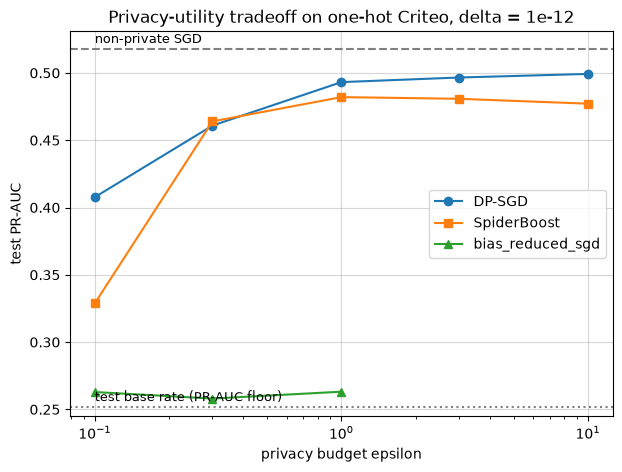

{'epsilon': [0.1, 0.3, 1.0, 3.0, 10.0], 'DP-SGD': [0.4076957093748532, 0.4608786023227937, 0.49317527424571245, 0.4965936483426079, 0.4992596074345286], 'SpiderBoost': [0.32886258843073457, 0.4639975836379686, 0.4820229518712573, 0.4807783992084476, 0.4771496288311577], 'bias_reduced_sgd': [0.26288362424007283, 0.2580548151002204, 0.2631515788974081, None, None], 'sgd_baseline': 0.5181154912413114, 'base_rate': 0.252, 'brs_realized': {0.1: (3000, 0.000642984739247971), 0.3: (3000, 0.0020726767153428963), 1.0: (3000, 0.007516871980524798)}}


In [11]:
fig, axis = plt.subplots(figsize=(7, 5))

for arm, marker in zip(PRIVATE_ARMS, ("o", "s", "^")):
    points = [(eps, RESULTS[arm][eps].pr_auc) for eps in SWEEP_EPSILONS
              if eps in RESULTS[arm] and np.isfinite(RESULTS[arm][eps].pr_auc)]
    axis.plot([eps for eps, _ in points], [value for _, value in points],
              marker=marker, label=arm)

axis.axhline(BASELINE.pr_auc, linestyle="--", color="grey")
axis.annotate("non-private SGD", xy=(SWEEP_EPSILONS[0], BASELINE.pr_auc),
              xytext=(0, 4), textcoords="offset points", fontsize=9)
axis.axhline(BASE_RATE, linestyle=":", color="grey")
axis.annotate("test base rate (PR-AUC floor)",
              xy=(SWEEP_EPSILONS[0], BASE_RATE), xytext=(0, 4),
              textcoords="offset points", fontsize=9)

axis.set_xscale("log")
axis.set_xlabel("privacy budget epsilon")
axis.set_ylabel("test PR-AUC")
axis.set_title(f"Privacy-utility tradeoff on one-hot Criteo, "
               f"delta = {TARGET_DELTA:.0e}")
axis.legend(loc="best")
axis.grid(alpha=0.5)
plt.show()

print({"epsilon": list(SWEEP_EPSILONS),
       **{arm: [RESULTS[arm][eps].pr_auc if eps in RESULTS[arm] else None
                for eps in SWEEP_EPSILONS] for arm in PRIVATE_ARMS},
       "sgd_baseline": BASELINE.pr_auc, "base_rate": BASE_RATE,
       "brs_realized": BRS_REALIZED})